# E-commerce Fraud Detection - Exploratory Data Analysis & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

In [6]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

Both datasets are loaded: transactional data and geolocation mapping data.

In [7]:
fraud_df.shape
fraud_df.info()
fraud_df.describe()
fraud_df.isnull().sum()
fraud_df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


np.int64(0)

The dataset is checked for structure, data types, missing values, and duplicates. No missing values or duplicates were found, indicating clean data.

In [8]:
fraud_df['class'].value_counts()
fraud_df['class'].value_counts(normalize=True) * 100


class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

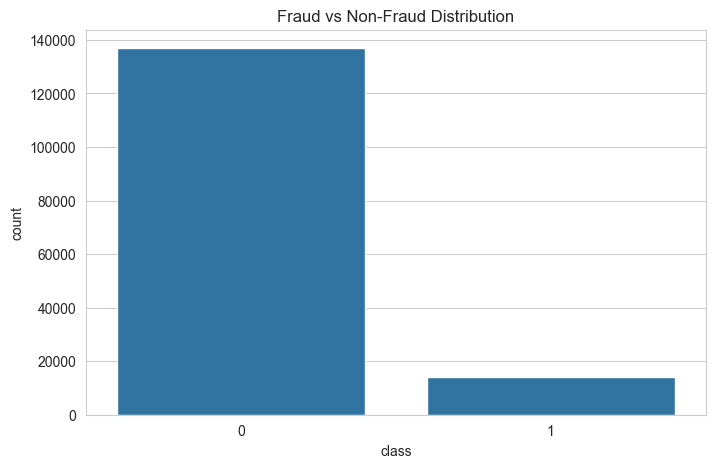

In [9]:
sns.countplot(data=fraud_df, x='class')
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

The dataset is highly imbalanced, with fraudulent transactions forming a small minority. This requires specialized modeling techniques.

In [10]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

Time columns are converted to datetime format to enable temporal feature engineering.

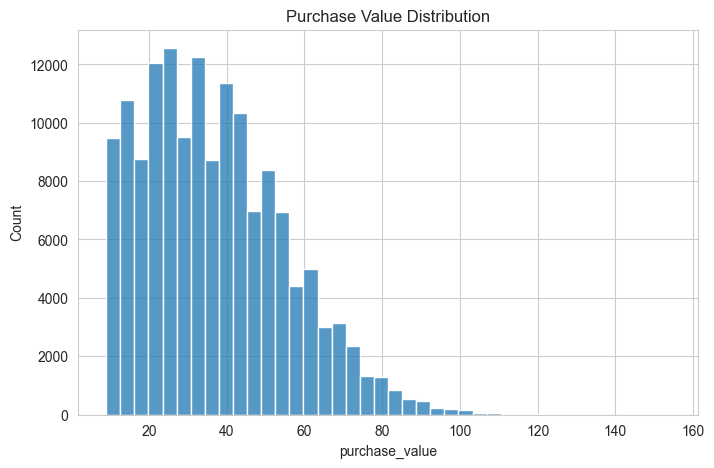

In [11]:
sns.histplot(fraud_df['purchase_value'], bins=40)
plt.title("Purchase Value Distribution")
plt.show()

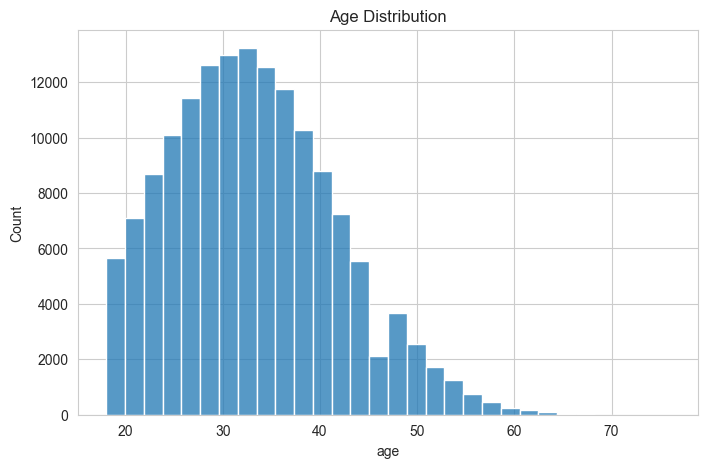

In [12]:
sns.histplot(fraud_df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

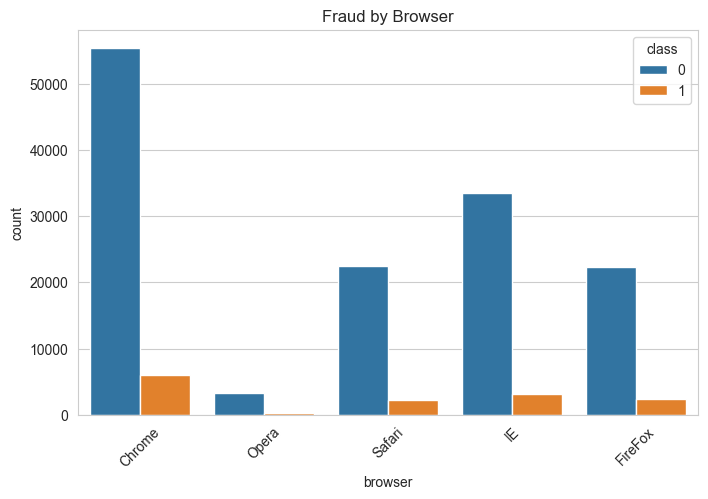

In [13]:
sns.countplot(data=fraud_df, x='browser', hue='class')
plt.xticks(rotation=45)
plt.title("Fraud by Browser")
plt.show()

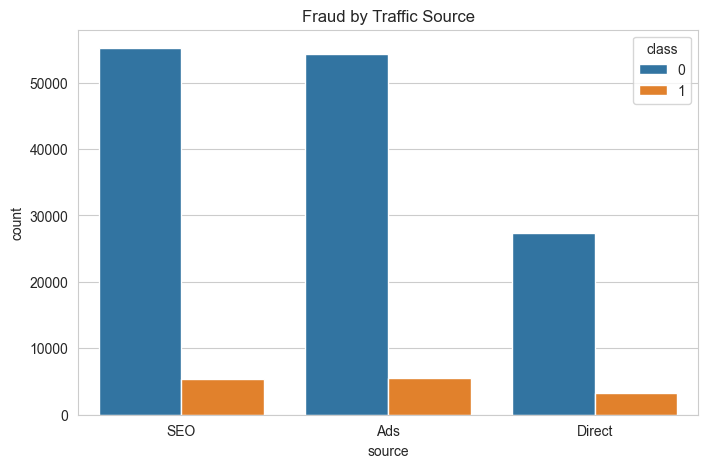

In [14]:
sns.countplot(data=fraud_df, x='source', hue='class')
plt.title("Fraud by Traffic Source")
plt.show()

Fraud behavior varies across user demographics and acquisition channels, showing behavioral patterns in fraud occurrence.

In [15]:
ip_df['lower_bound_ip_address'] = ip_df['lower_bound_ip_address'].astype(np.int64)
ip_df['upper_bound_ip_address'] = ip_df['upper_bound_ip_address'].astype(np.int64)
fraud_df['ip_address'] = fraud_df['ip_address'].astype(np.int64)

In [16]:
fraud_df = fraud_df.sort_values('ip_address')
ip_df = ip_df.sort_values('lower_bound_ip_address')

In [17]:
merged_df = pd.merge_asof(
    fraud_df,
    ip_df,
    left_on='ip_address',
    right_on='lower_bound_ip_address',
    direction='backward'
)

In [18]:
merged_df = merged_df[
    merged_df['ip_address'] <= merged_df['upper_bound_ip_address']
]

IP addresses are mapped to countries using range-based lookup to enrich transactions with geolocation data.

In [19]:
country_fraud = merged_df.groupby('country')['class'].mean().sort_values(ascending=False).head(10)
country_fraud

country
Turkmenistan             1.000000
Namibia                  0.434783
Sri Lanka                0.419355
Luxembourg               0.388889
Virgin Islands (U.S.)    0.333333
Ecuador                  0.264151
Tunisia                  0.262712
Peru                     0.260504
Bolivia                  0.245283
Kuwait                   0.233333
Name: class, dtype: float64

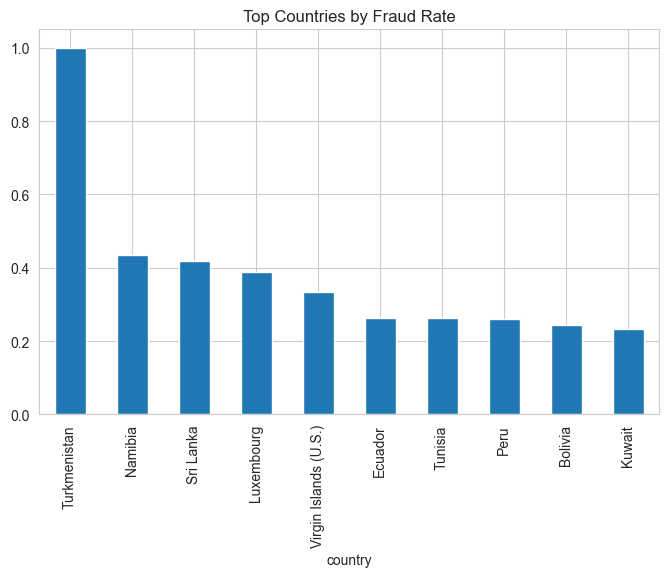

In [20]:
country_fraud.plot(kind='bar')
plt.title("Top Countries by Fraud Rate")
plt.show()

fraud rates differ significantly across countries, showing that geographic location is a strong predictive signal.

In [21]:
merged_df['time_since_signup'] = (
    merged_df['purchase_time'] - merged_df['signup_time']
).dt.total_seconds()

In [22]:
merged_df['hour_of_day'] = merged_df['purchase_time'].dt.hour
merged_df['day_of_week'] = merged_df['purchase_time'].dt.dayofweek

In [23]:
user_freq = merged_df['user_id'].value_counts()
merged_df['transaction_count'] = merged_df['user_id'].map(user_freq)

Behavioral features are created to capture fraud patterns such as rapid purchases, unusual timing, and abnormal user activity frequency

In [24]:
df = merged_df.copy()
df = df.drop(['signup_time', 'purchase_time'], axis=1)
df.head()

,user_id,purchase_value,device_id,source,browser,sex,age,ip_address,class,lower_bound_ip_address,upper_bound_ip_address,country,time_since_signup,hour_of_day,day_of_week,transaction_count
634,247547,47,KIXYSVCHIPQBR,SEO,Safari,F,30,16778864,0,16778240.0,16779263.0,Australia,3632215.0,3,6,1
635,220737,15,PKYOWQKWGJNJI,SEO,Chrome,F,34,16842045,0,16809984.0,16842751.0,Thailand,1231637.0,20,2,1
636,390400,44,LVCSXLISZHVUO,Ads,IE,M,29,16843656,0,16843264.0,16843775.0,China,1997534.0,23,5,1
637,69592,55,UHAUHNXXUADJE,Direct,Chrome,F,30,16938732,0,16924672.0,16941055.0,China,7640897.0,16,5,1
638,174987,51,XPGPMOHIDRMGE,SEO,Chrome,F,37,16971984,0,16941056.0,16973823.0,Thailand,10249579.0,4,1,1


Raw timestamp columns are removed after extracting meaningful features.

## Key Insights

- The dataset is highly imbalanced, requiring specialized evaluation metrics.
- Fraud behavior is strongly influenced by time-based patterns.
- Geolocation (country) is a strong predictor of fraud risk.
- Rapid transactions after signup are highly suspicious.
- User activity frequency is a strong behavioral indicator of fraud.

## Class Imbalance Handling Strategy

Both datasets exhibit significant class imbalance, where fraudulent transactions represent only a small proportion of observations.

To address this issue during model development, SMOTE (Synthetic Minority Over-sampling Technique) will be applied only to the training data after performing a stratified train-test split. This prevents information leakage from the training set into the test set and ensures that evaluation metrics reflect real-world performance.

F1-score and AUC-PR will be prioritized over accuracy because they provide more reliable evaluation for highly imbalanced classification problems.
